**06_focal_loss_experiments.ipynb: Focal Loss & Class Imbalance Experiments**

**Multimodal Financial Fraud / Risk Detector**  
This notebook implements **Phase 7: Focal Loss & Imbalance Experiments**.  
In Phase 6, we demonstrated that categorical entity embeddings provide strong predictive gains over a numerical-only architecture. Now, we investigate the fundamental loss formulation under severe class imbalance (2.68% fraud rate in training, ~36:1 negative-to-positive ratio).

```
LOSS COMPARISON UNDER SEVERE CLASS IMBALANCE
Standard BCE:      L(p_t) = -log(p_t)                     (all samples weighted equally)
Weighted BCE:      L(p_t) = -w_t * log(p_t)               (static multiplier w_1 = 36.34)
Focal Loss:        L(p_t) = -(1 - p_t)^gamma * log(p_t)   (dynamic loss modulation)
```

**Core Scientific Question**:  
*Does dynamically reducing the gradient contribution of easy non-fraud transactions via Focal Loss (with varying focusing parameter gamma in {1.0, 2.0, 3.0}) improve fraud detection performance and decision threshold calibration compared with static positive-class weighting?*


**1. Load Dataset, Preprocessor & Setup PyTorch Environment**

We load the IEEE-CIS transaction and identity data using our memory-optimized data loader and execute the strict 70/15/15 chronological temporal split. Preprocessing is fitted strictly on `train_df`.


In [1]:
import sys
from pathlib import Path

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from src.preprocessing import (
    load_and_merge_data,
    temporal_train_val_test_split,
    TabularPreprocessor
)
from src.dataset import FraudDataset, create_dataloaders
from src.model import HybridFraudDetector, compute_embedding_dim
from src.losses import FocalLoss, WeightedBCELoss, get_loss_function
from src.train import train_model, evaluate_dataloader
from src.evaluate import (
    compute_fraud_metrics,
    evaluate_thresholds,
    find_optimal_threshold,
    plot_confusion_matrix,
    plot_pr_curves,
    plot_roc_curves
)

# Plotting styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

FIG_DIR = PROJECT_ROOT / "results" / "figures"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
MODELS_DIR = PROJECT_ROOT / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__} | Active Device: {device}")

NROWS = 100_000
data_dir = PROJECT_ROOT / "data" / "raw"
print(f"Loading merged dataset (nrows={NROWS})...")
df = load_and_merge_data(data_dir=data_dir, split="train", nrows=NROWS, reduce_memory=True, verbose=False)

# Strict Chronological Temporal Split
train_df, val_df, test_df = temporal_train_val_test_split(df, val_ratio=0.15, test_ratio=0.15)

# Fit TabularPreprocessor strictly on training split
preprocessor = TabularPreprocessor(min_freq=10, log_transform_amt=True, drop_zero_variance=True)
preprocessor.fit(train_df)

X_num_train, X_cat_train, y_train = preprocessor.transform(train_df)
X_num_val, X_cat_val, y_val = preprocessor.transform(val_df)
X_num_test, X_cat_test, y_test = preprocessor.transform(test_df)

cat_feature_names = preprocessor.fitted_categorical_cols_
cat_vocab_sizes = [preprocessor.vocab_sizes_[col] for col in cat_feature_names]
embedding_dims = [compute_embedding_dim(v) for v in cat_vocab_sizes]
num_features = X_num_train.shape[1]

# Create DataLoaders
BATCH_SIZE = 512
train_dataset = FraudDataset(X_num_train, X_cat_train, y_train)
val_dataset = FraudDataset(X_num_val, X_cat_val, y_val)
test_dataset = FraudDataset(X_num_test, X_cat_test, y_test)

loaders = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0
)
train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

imbalance_ratio = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"Setup complete: {num_features} numericals, {len(cat_feature_names)} categoricals (sum dim={sum(embedding_dims)}).")
print(f"Class Imbalance Ratio (Negatives / Positives): {imbalance_ratio:.2f}")


PyTorch Version: 2.14.0+cpu | Active Device: cpu
Loading merged dataset (nrows=100000)...


2026-10-02 11:55:35,611 - INFO - Sorting dataset by 'TransactionDT' for strict chronological temporal splitting...


2026-10-02 11:55:36,039 - INFO - Temporal Split Completed Successfully:


2026-10-02 11:55:36,042 - INFO -   [TRAIN] Rows: 70,000 (70.0%) | DT: [86,400 - 1,564,844] (~17.1 days), Frauds=1879 (2.68%)


2026-10-02 11:55:36,043 - INFO -   [VAL] Rows: 15,000 (15.0%) | DT: [1,564,850 - 1,804,023] (~2.8 days), Frauds=377 (2.51%)


...

2026-10-02 11:55:38,431 - INFO - Built vocabularies for 49 categorical features (min_freq=10).


2026-10-02 11:55:40,528 - INFO - Created 'train' DataLoader: 70,000 samples, 137 batches (batch_size=512)


2026-10-02 11:55:40,529 - INFO - Created 'val' DataLoader: 15,000 samples, 30 batches (batch_size=512)


2026-10-02 11:55:40,529 - INFO - Created 'test' DataLoader: 15,000 samples, 30 batches (batch_size=512)


Setup complete: 381 numericals, 49 categoricals (sum dim=568).
Class Imbalance Ratio (Negatives / Positives): 36.25


**2. Evaluate Reference Baselines: Standard BCE & Weighted BCE**

We load the trained weights for Model E (Standard BCE) and Model F (Weighted BCE with `pos_weight = 36.34`) saved during Phase 6. We re-verify their validation-selected optimal thresholds and final test set metrics to maintain complete experimental continuity.


In [2]:
# 1. Model E: Hybrid + Standard BCE
model_bce = HybridFraudDetector(
    num_numerical_features=num_features,
    categorical_cardinalities=cat_vocab_sizes,
    embedding_dims=embedding_dims
).to(device)
model_bce.load_state_dict(torch.load(MODELS_DIR / "pytorch_hybrid_standard_bce.pt", map_location=device))
criterion_bce = nn.BCEWithLogitsLoss()

_, val_metrics_bce, y_val_true, y_val_prob_bce = evaluate_dataloader(model_bce, val_loader, criterion_bce, device)
_, _, y_test_true, y_test_prob_bce = evaluate_dataloader(model_bce, test_loader, criterion_bce, device)
opt_thresh_bce, _ = find_optimal_threshold(y_val_true, y_val_prob_bce, metric="F1")
test_metrics_bce = compute_fraud_metrics(y_test_true, y_test_prob_bce, threshold=opt_thresh_bce)

# 2. Model F: Hybrid + Weighted BCE
pos_weight_tensor = torch.tensor([imbalance_ratio], dtype=torch.float32).to(device)
criterion_wbce = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
model_wbce = HybridFraudDetector(
    num_numerical_features=num_features,
    categorical_cardinalities=cat_vocab_sizes,
    embedding_dims=embedding_dims
).to(device)
model_wbce.load_state_dict(torch.load(MODELS_DIR / "pytorch_hybrid_weighted_bce.pt", map_location=device))

_, val_metrics_wbce, _, y_val_prob_wbce = evaluate_dataloader(model_wbce, val_loader, criterion_wbce, device)
_, _, _, y_test_prob_wbce = evaluate_dataloader(model_wbce, test_loader, criterion_wbce, device)
opt_thresh_wbce, _ = find_optimal_threshold(y_val_true, y_val_prob_wbce, metric="F1")
test_metrics_wbce = compute_fraud_metrics(y_test_true, y_test_prob_wbce, threshold=opt_thresh_wbce)

print("=== Reference Baselines (Phase 6) ===")
print(f"Hybrid Standard BCE: Val PR-AUC={val_metrics_bce['PR-AUC']:.4f} | Test PR-AUC={test_metrics_bce['PR-AUC']:.4f} | Opt Thresh={opt_thresh_bce:.2f} | Precision={test_metrics_bce['Precision']:.4f} | Recall={test_metrics_bce['Recall']:.4f} | F1={test_metrics_bce['F1']:.4f} | FP={test_metrics_bce['FP']}")
print(f"Hybrid Weighted BCE: Val PR-AUC={val_metrics_wbce['PR-AUC']:.4f} | Test PR-AUC={test_metrics_wbce['PR-AUC']:.4f} | Opt Thresh={opt_thresh_wbce:.2f} | Precision={test_metrics_wbce['Precision']:.4f} | Recall={test_metrics_wbce['Recall']:.4f} | F1={test_metrics_wbce['F1']:.4f} | FP={test_metrics_wbce['FP']}")


=== Reference Baselines (Phase 6) ===
Hybrid Standard BCE: Val PR-AUC=0.5772 | Test PR-AUC=0.4623 | Opt Thresh=0.20 | Precision=0.4783 | Recall=0.4328 | F1=0.4544 | FP=144
Hybrid Weighted BCE: Val PR-AUC=0.5368 | Test PR-AUC=0.4627 | Opt Thresh=0.95 | Precision=0.5833 | Recall=0.4361 | F1=0.4991 | FP=95


**3. Experiment 7A: Hybrid Network + Focal Loss (gamma = 1.0)**

With gamma = 1.0, the loss function applies a linear modulating factor $(1 - p_t)^1$. Easy non-fraud transactions with $p pprox 0.01$ receive approximately a 100x attenuation in gradient impact compared to misclassified fraud transactions.


In [3]:
print("=== Running Experiment 7A: Focal Loss (gamma = 1.0) ===")
torch.manual_seed(42)
np.random.seed(42)

model_focal_g1 = HybridFraudDetector(
    num_numerical_features=num_features,
    categorical_cardinalities=cat_vocab_sizes,
    embedding_dims=embedding_dims
).to(device)

criterion_focal_g1 = FocalLoss(gamma=1.0)
optimizer_focal_g1 = AdamW(model_focal_g1.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_focal_g1 = ReduceLROnPlateau(optimizer_focal_g1, mode="max", factor=0.5, patience=2)

checkpoint_focal_g1 = MODELS_DIR / "pytorch_hybrid_focal_gamma1.pt"

model_focal_g1, history_focal_g1 = train_model(
    model=model_focal_g1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_focal_g1,
    optimizer=optimizer_focal_g1,
    scheduler=scheduler_focal_g1,
    num_epochs=12,
    patience=5,
    device=device,
    checkpoint_path=checkpoint_focal_g1,
    monitor_metric="PR-AUC",
    verbose=True
)

_, val_metrics_focal_g1, _, y_val_prob_focal_g1 = evaluate_dataloader(model_focal_g1, val_loader, criterion_focal_g1, device)
_, _, _, y_test_prob_focal_g1 = evaluate_dataloader(model_focal_g1, test_loader, criterion_focal_g1, device)

opt_thresh_focal_g1, _ = find_optimal_threshold(y_val_true, y_val_prob_focal_g1, metric="F1")
test_metrics_focal_g1 = compute_fraud_metrics(y_test_true, y_test_prob_focal_g1, threshold=opt_thresh_focal_g1)

print(f"\nExperiment 7A Results (Focal gamma=1.0):")
print(f"  Validation: PR-AUC={val_metrics_focal_g1['PR-AUC']:.4f}, ROC-AUC={val_metrics_focal_g1['ROC-AUC']:.4f}, Opt Threshold={opt_thresh_focal_g1:.2f}")
print(f"  Test:       PR-AUC={test_metrics_focal_g1['PR-AUC']:.4f}, ROC-AUC={test_metrics_focal_g1['ROC-AUC']:.4f}, F1={test_metrics_focal_g1['F1']:.4f}, Recall={test_metrics_focal_g1['Recall']:.4f}, Precision={test_metrics_focal_g1['Precision']:.4f}, FP={test_metrics_focal_g1['FP']}")


=== Running Experiment 7A: Focal Loss (gamma = 1.0) ===


2026-10-02 11:55:44,479 - INFO - Starting training for up to 12 epochs on cpu (Monitoring: PR-AUC)...


2026-10-02 11:55:50,116 - INFO - Epoch  1/12 | Train Loss: 0.1015 | Val Loss: 0.0447 | Val PR-AUC: 0.4279 | Val ROC-AUC: 0.8719 | Val F1: 0.2506 | LR: 1.00e-03


2026-10-02 11:55:50,117 - INFO - Validation metric improved (None -> 0.4279). Saving checkpoint...


2026-10-02 11:55:55,957 - INFO - Epoch  2/12 | Train Loss: 0.0459 | Val Loss: 0.0380 | Val PR-AUC: 0.5026 | Val ROC-AUC: 0.8956 | Val F1: 0.4346 | LR: 1.00e-03


...

2026-10-02 11:56:46,931 - INFO - Validation metric improved (0.5548 -> 0.5671). Saving checkpoint...


2026-10-02 11:56:52,658 - INFO - Epoch 12/12 | Train Loss: 0.0174 | Val Loss: 0.0432 | Val PR-AUC: 0.5437 | Val ROC-AUC: 0.8712 | Val F1: 0.5608 | LR: 5.00e-04


2026-10-02 11:56:52,658 - INFO - EarlyStopping counter: 1/5 (Best: 0.5671 at Epoch 11)


2026-10-02 11:56:52,662 - INFO - Restored best model weights from epoch 11 with PR-AUC = 0.5671



Experiment 7A Results (Focal gamma=1.0):
  Validation: PR-AUC=0.5671, ROC-AUC=0.8832, Opt Threshold=0.35
  Test:       PR-AUC=0.4402, ROC-AUC=0.8480, F1=0.4586, Recall=0.4262, Precision=0.4962, FP=132


**4. Experiment 7B: Hybrid Network + Focal Loss (gamma = 2.0)**

With gamma = 2.0 (the standard parameter from Lin et al., 2017), the loss applies quadratic down-weighting $(1 - p_t)^2$. Easy negative examples with $p pprox 0.05$ have their gradient contribution suppressed by a factor of 400.


In [4]:
print("=== Running Experiment 7B: Focal Loss (gamma = 2.0) ===")
torch.manual_seed(42)
np.random.seed(42)

model_focal_g2 = HybridFraudDetector(
    num_numerical_features=num_features,
    categorical_cardinalities=cat_vocab_sizes,
    embedding_dims=embedding_dims
).to(device)

criterion_focal_g2 = FocalLoss(gamma=2.0)
optimizer_focal_g2 = AdamW(model_focal_g2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_focal_g2 = ReduceLROnPlateau(optimizer_focal_g2, mode="max", factor=0.5, patience=2)

checkpoint_focal_g2 = MODELS_DIR / "pytorch_hybrid_focal_gamma2.pt"

model_focal_g2, history_focal_g2 = train_model(
    model=model_focal_g2,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_focal_g2,
    optimizer=optimizer_focal_g2,
    scheduler=scheduler_focal_g2,
    num_epochs=12,
    patience=5,
    device=device,
    checkpoint_path=checkpoint_focal_g2,
    monitor_metric="PR-AUC",
    verbose=True
)

_, val_metrics_focal_g2, _, y_val_prob_focal_g2 = evaluate_dataloader(model_focal_g2, val_loader, criterion_focal_g2, device)
_, _, _, y_test_prob_focal_g2 = evaluate_dataloader(model_focal_g2, test_loader, criterion_focal_g2, device)

opt_thresh_focal_g2, _ = find_optimal_threshold(y_val_true, y_val_prob_focal_g2, metric="F1")
test_metrics_focal_g2 = compute_fraud_metrics(y_test_true, y_test_prob_focal_g2, threshold=opt_thresh_focal_g2)

print(f"\nExperiment 7B Results (Focal gamma=2.0):")
print(f"  Validation: PR-AUC={val_metrics_focal_g2['PR-AUC']:.4f}, ROC-AUC={val_metrics_focal_g2['ROC-AUC']:.4f}, Opt Threshold={opt_thresh_focal_g2:.2f}")
print(f"  Test:       PR-AUC={test_metrics_focal_g2['PR-AUC']:.4f}, ROC-AUC={test_metrics_focal_g2['ROC-AUC']:.4f}, F1={test_metrics_focal_g2['F1']:.4f}, Recall={test_metrics_focal_g2['Recall']:.4f}, Precision={test_metrics_focal_g2['Precision']:.4f}, FP={test_metrics_focal_g2['FP']}")


2026-10-02 11:56:53,697 - INFO - Starting training for up to 12 epochs on cpu (Monitoring: PR-AUC)...


=== Running Experiment 7B: Focal Loss (gamma = 2.0) ===


2026-10-02 11:56:59,217 - INFO - Epoch  1/12 | Train Loss: 0.0496 | Val Loss: 0.0240 | Val PR-AUC: 0.4168 | Val ROC-AUC: 0.8768 | Val F1: 0.2483 | LR: 1.00e-03


2026-10-02 11:56:59,218 - INFO - Validation metric improved (None -> 0.4168). Saving checkpoint...


2026-10-02 11:57:04,850 - INFO - Epoch  2/12 | Train Loss: 0.0256 | Val Loss: 0.0211 | Val PR-AUC: 0.5171 | Val ROC-AUC: 0.8909 | Val F1: 0.4528 | LR: 1.00e-03


...

2026-10-02 11:58:05,639 - INFO - Epoch 12/12 | Train Loss: 0.0098 | Val Loss: 0.0276 | Val PR-AUC: 0.5340 | Val ROC-AUC: 0.8544 | Val F1: 0.5624 | LR: 5.00e-04


2026-10-02 11:58:05,640 - INFO - EarlyStopping counter: 5/5 (Best: 0.5643 at Epoch 7)


2026-10-02 11:58:05,641 - INFO - Early stopping triggered. Restoring best weights from epoch 7.


2026-10-02 11:58:05,644 - INFO - Restored best model weights from epoch 7 with PR-AUC = 0.5643



Experiment 7B Results (Focal gamma=2.0):
  Validation: PR-AUC=0.5643, ROC-AUC=0.8769, Opt Threshold=0.35
  Test:       PR-AUC=0.4247, ROC-AUC=0.8303, F1=0.4520, Recall=0.4164, Precision=0.4942, FP=130


**5. Experiment 7C: Hybrid Network + Focal Loss (gamma = 3.0)**

With gamma = 3.0, the cubic focusing factor $(1 - p_t)^3$ exerts very aggressive suppression on well-classified instances. This tests whether extreme focus on ambiguous boundary examples prevents gradient dilution or leads to training instability.


In [5]:
print("=== Running Experiment 7C: Focal Loss (gamma = 3.0) ===")
torch.manual_seed(42)
np.random.seed(42)

model_focal_g3 = HybridFraudDetector(
    num_numerical_features=num_features,
    categorical_cardinalities=cat_vocab_sizes,
    embedding_dims=embedding_dims
).to(device)

criterion_focal_g3 = FocalLoss(gamma=3.0)
optimizer_focal_g3 = AdamW(model_focal_g3.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_focal_g3 = ReduceLROnPlateau(optimizer_focal_g3, mode="max", factor=0.5, patience=2)

checkpoint_focal_g3 = MODELS_DIR / "pytorch_hybrid_focal_gamma3.pt"

model_focal_g3, history_focal_g3 = train_model(
    model=model_focal_g3,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_focal_g3,
    optimizer=optimizer_focal_g3,
    scheduler=scheduler_focal_g3,
    num_epochs=12,
    patience=5,
    device=device,
    checkpoint_path=checkpoint_focal_g3,
    monitor_metric="PR-AUC",
    verbose=True
)

_, val_metrics_focal_g3, _, y_val_prob_focal_g3 = evaluate_dataloader(model_focal_g3, val_loader, criterion_focal_g3, device)
_, _, _, y_test_prob_focal_g3 = evaluate_dataloader(model_focal_g3, test_loader, criterion_focal_g3, device)

opt_thresh_focal_g3, _ = find_optimal_threshold(y_val_true, y_val_prob_focal_g3, metric="F1")
test_metrics_focal_g3 = compute_fraud_metrics(y_test_true, y_test_prob_focal_g3, threshold=opt_thresh_focal_g3)

print(f"\nExperiment 7C Results (Focal gamma=3.0):")
print(f"  Validation: PR-AUC={val_metrics_focal_g3['PR-AUC']:.4f}, ROC-AUC={val_metrics_focal_g3['ROC-AUC']:.4f}, Opt Threshold={opt_thresh_focal_g3:.2f}")
print(f"  Test:       PR-AUC={test_metrics_focal_g3['PR-AUC']:.4f}, ROC-AUC={test_metrics_focal_g3['ROC-AUC']:.4f}, F1={test_metrics_focal_g3['F1']:.4f}, Recall={test_metrics_focal_g3['Recall']:.4f}, Precision={test_metrics_focal_g3['Precision']:.4f}, FP={test_metrics_focal_g3['FP']}")


2026-10-02 11:58:06,717 - INFO - Starting training for up to 12 epochs on cpu (Monitoring: PR-AUC)...


=== Running Experiment 7C: Focal Loss (gamma = 3.0) ===


2026-10-02 11:58:12,469 - INFO - Epoch  1/12 | Train Loss: 0.0259 | Val Loss: 0.0128 | Val PR-AUC: 0.4625 | Val ROC-AUC: 0.8797 | Val F1: 0.2356 | LR: 1.00e-03


2026-10-02 11:58:12,470 - INFO - Validation metric improved (None -> 0.4625). Saving checkpoint...


2026-10-02 11:58:18,755 - INFO - Epoch  2/12 | Train Loss: 0.0142 | Val Loss: 0.0118 | Val PR-AUC: 0.4855 | Val ROC-AUC: 0.8909 | Val F1: 0.4369 | LR: 1.00e-03


...

2026-10-02 11:59:11,278 - INFO - Epoch 11/12 | Train Loss: 0.0060 | Val Loss: 0.0147 | Val PR-AUC: 0.4920 | Val ROC-AUC: 0.8796 | Val F1: 0.5415 | LR: 5.00e-04


2026-10-02 11:59:11,279 - INFO - EarlyStopping counter: 5/5 (Best: 0.5555 at Epoch 6)


2026-10-02 11:59:11,280 - INFO - Early stopping triggered. Restoring best weights from epoch 6.


2026-10-02 11:59:11,285 - INFO - Restored best model weights from epoch 6 with PR-AUC = 0.5555



Experiment 7C Results (Focal gamma=3.0):
  Validation: PR-AUC=0.5555, ROC-AUC=0.8946, Opt Threshold=0.45
  Test:       PR-AUC=0.4257, ROC-AUC=0.8497, F1=0.4612, Recall=0.4000, Precision=0.5446, FP=102


**6. Comparative Training Trajectories & Validation PR-AUC Evolution**

We analyze the convergence dynamics across the different loss formulations. Note that because Focal Loss attenuates the magnitude of easy sample loss terms, absolute focal loss values are naturally smaller than standard BCE. The meaningful cross-model comparison metric is the validation PR-AUC progression over epochs.


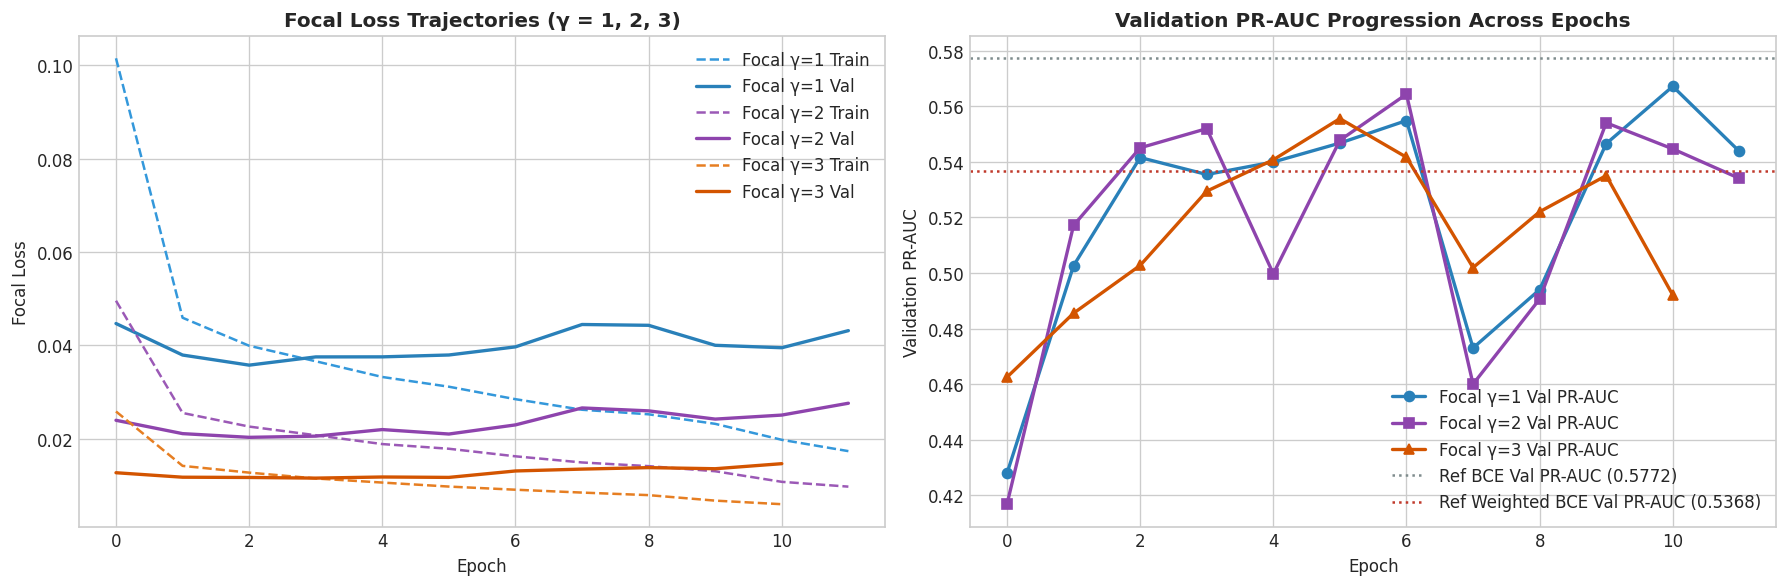

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Focal Loss Trajectories (Comparable Scale)
axes[0].plot(history_focal_g1["train_loss"], label="Focal γ=1 Train", color="#3498db", linestyle="--")
axes[0].plot(history_focal_g1["val_loss"], label="Focal γ=1 Val", color="#2980b9", lw=2)
axes[0].plot(history_focal_g2["train_loss"], label="Focal γ=2 Train", color="#9b59b6", linestyle="--")
axes[0].plot(history_focal_g2["val_loss"], label="Focal γ=2 Val", color="#8e44ad", lw=2)
axes[0].plot(history_focal_g3["train_loss"], label="Focal γ=3 Train", color="#e67e22", linestyle="--")
axes[0].plot(history_focal_g3["val_loss"], label="Focal γ=3 Val", color="#d35400", lw=2)
axes[0].set_title("Focal Loss Trajectories (γ = 1, 2, 3)", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Focal Loss")
axes[0].legend()

# Plot Validation PR-AUC Evolution across all 3 Focal Models
axes[1].plot(history_focal_g1["val_pr_auc"], label="Focal γ=1 Val PR-AUC", color="#2980b9", lw=2, marker="o")
axes[1].plot(history_focal_g2["val_pr_auc"], label="Focal γ=2 Val PR-AUC", color="#8e44ad", lw=2, marker="s")
axes[1].plot(history_focal_g3["val_pr_auc"], label="Focal γ=3 Val PR-AUC", color="#d35400", lw=2, marker="^")
axes[1].axhline(y=val_metrics_bce["PR-AUC"], color="#7f8c8d", linestyle=":", label=f"Ref BCE Val PR-AUC ({val_metrics_bce['PR-AUC']:.4f})")
axes[1].axhline(y=val_metrics_wbce["PR-AUC"], color="#c0392b", linestyle=":", label=f"Ref Weighted BCE Val PR-AUC ({val_metrics_wbce['PR-AUC']:.4f})")
axes[1].set_title("Validation PR-AUC Progression Across Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation PR-AUC")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "loss_curves_focal_experiments.png")
plt.show()


**7. Precision-Recall Curves & Decision Threshold Distribution**

We generate precision-recall curves on the test set comparing all 5 loss configurations. We also visualize how the loss formulation systematically shifts the optimal operating threshold $\theta^*$ and output probability distribution.


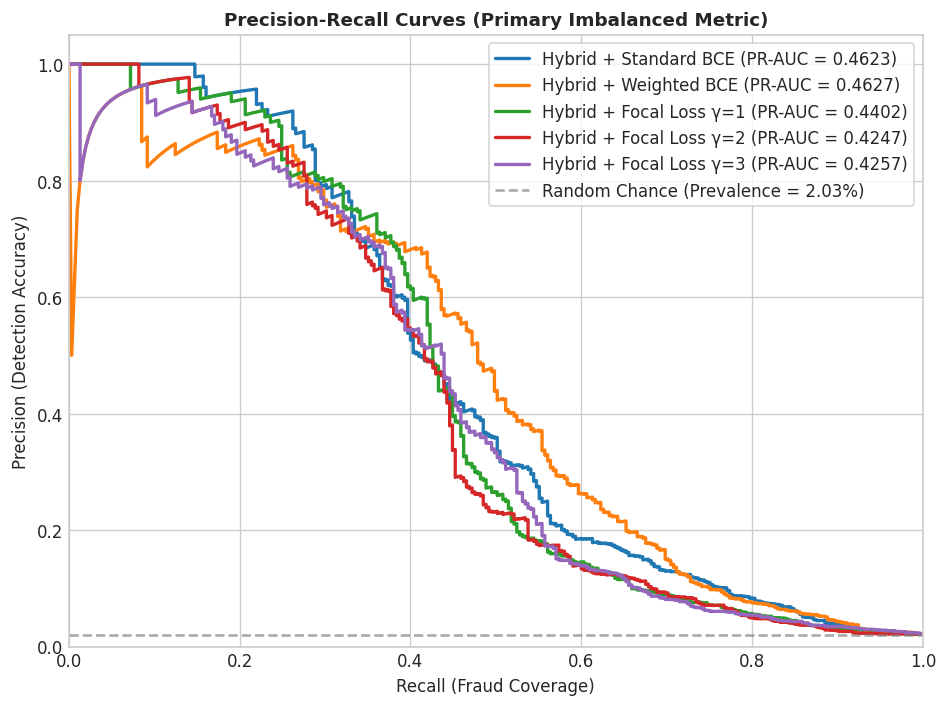

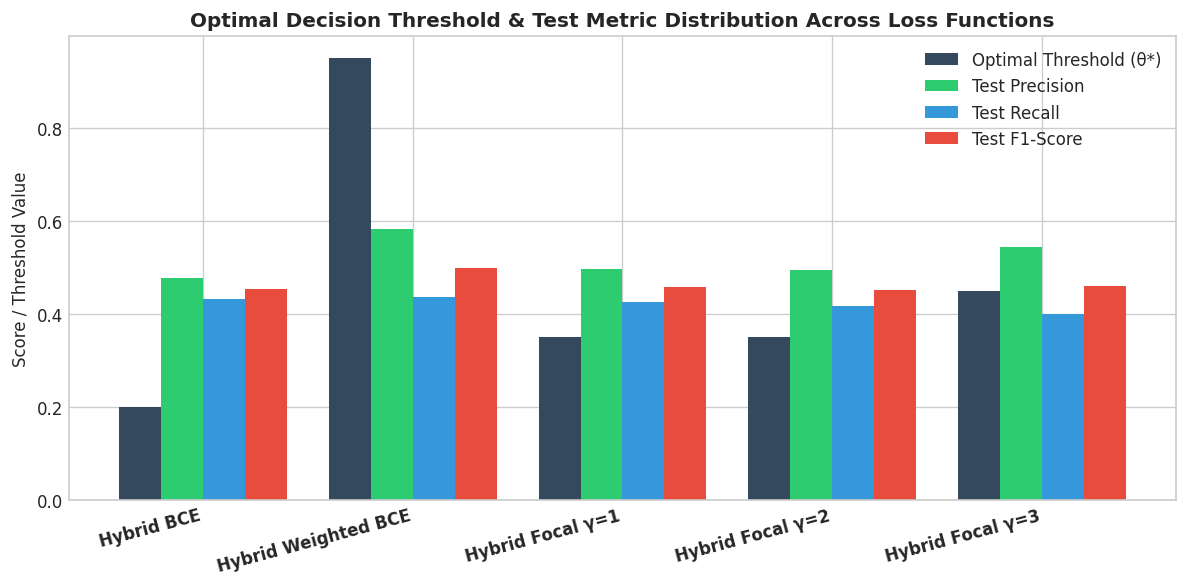

In [7]:
models_predictions = {
    "Hybrid + Standard BCE": (y_test_true, y_test_prob_bce),
    "Hybrid + Weighted BCE": (y_test_true, y_test_prob_wbce),
    "Hybrid + Focal Loss γ=1": (y_test_true, y_test_prob_focal_g1),
    "Hybrid + Focal Loss γ=2": (y_test_true, y_test_prob_focal_g2),
    "Hybrid + Focal Loss γ=3": (y_test_true, y_test_prob_focal_g3)
}

fig_pr = plot_pr_curves(models_predictions, save_path=FIG_DIR / "pr_curves_focal_experiments.png")
plt.show()

# Decision Threshold Sensitivity Plot
fig, ax = plt.subplots(figsize=(10, 5))
threshold_data = [
    {"Model": "Hybrid BCE", "Opt_Threshold": opt_thresh_bce, "Precision": test_metrics_bce["Precision"], "Recall": test_metrics_bce["Recall"], "F1": test_metrics_bce["F1"]},
    {"Model": "Hybrid Weighted BCE", "Opt_Threshold": opt_thresh_wbce, "Precision": test_metrics_wbce["Precision"], "Recall": test_metrics_wbce["Recall"], "F1": test_metrics_wbce["F1"]},
    {"Model": "Hybrid Focal γ=1", "Opt_Threshold": opt_thresh_focal_g1, "Precision": test_metrics_focal_g1["Precision"], "Recall": test_metrics_focal_g1["Recall"], "F1": test_metrics_focal_g1["F1"]},
    {"Model": "Hybrid Focal γ=2", "Opt_Threshold": opt_thresh_focal_g2, "Precision": test_metrics_focal_g2["Precision"], "Recall": test_metrics_focal_g2["Recall"], "F1": test_metrics_focal_g2["F1"]},
    {"Model": "Hybrid Focal γ=3", "Opt_Threshold": opt_thresh_focal_g3, "Precision": test_metrics_focal_g3["Precision"], "Recall": test_metrics_focal_g3["Recall"], "F1": test_metrics_focal_g3["F1"]}
]
df_thresh = pd.DataFrame(threshold_data)

x_pos = np.arange(len(df_thresh))
width = 0.2

ax.bar(x_pos - 1.5*width, df_thresh["Opt_Threshold"], width=width, label="Optimal Threshold (θ*)", color="#34495e")
ax.bar(x_pos - 0.5*width, df_thresh["Precision"], width=width, label="Test Precision", color="#2ecc71")
ax.bar(x_pos + 0.5*width, df_thresh["Recall"], width=width, label="Test Recall", color="#3498db")
ax.bar(x_pos + 1.5*width, df_thresh["F1"], width=width, label="Test F1-Score", color="#e74c3c")

ax.set_xticks(x_pos)
ax.set_xticklabels(df_thresh["Model"], rotation=15, ha="right", fontweight="bold")
ax.set_ylabel("Score / Threshold Value")
ax.set_title("Optimal Decision Threshold & Test Metric Distribution Across Loss Functions", fontweight="bold")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "threshold_distribution_focal.png")
plt.show()


**8. Confusion Matrices for Focal Loss Models**

We visualize the exact True Positives (caught frauds), False Positives (false alerts causing operational burden), False Negatives (missed frauds causing direct financial loss), and True Negatives at each model's validation-tuned threshold.


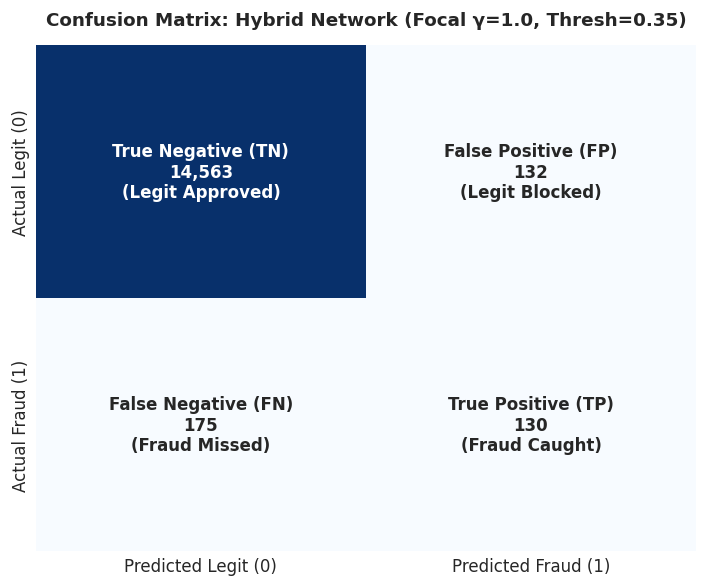

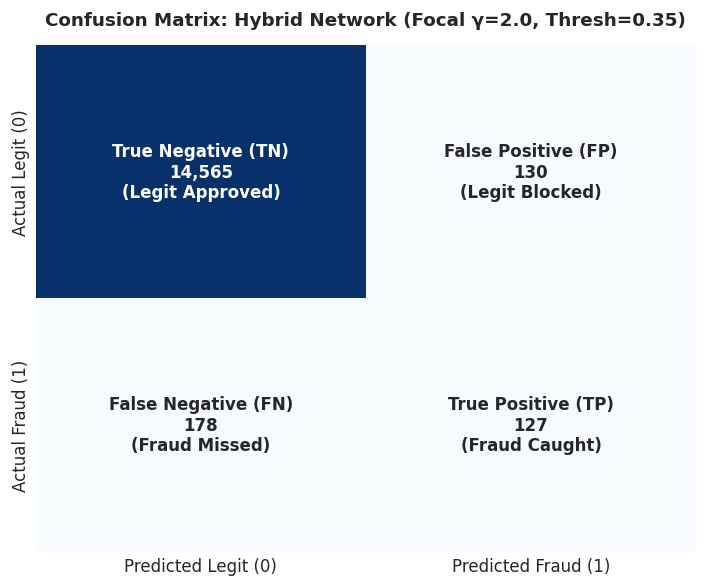

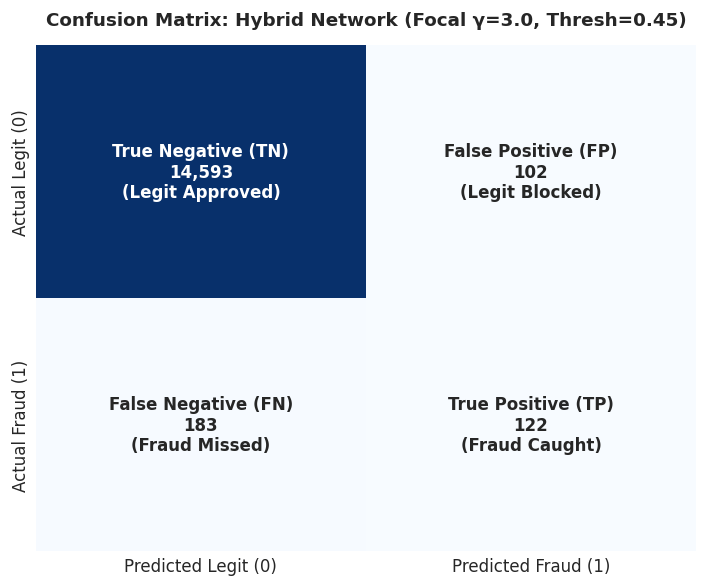

In [8]:
cm_focal_g1 = plot_confusion_matrix(
    y_test_true,
    (y_test_prob_focal_g1 >= opt_thresh_focal_g1).astype(int),
    f"Hybrid Network (Focal γ=1.0, Thresh={opt_thresh_focal_g1:.2f})",
    FIG_DIR / "confusion_matrix_focal_gamma1.png"
)
plt.show()

cm_focal_g2 = plot_confusion_matrix(
    y_test_true,
    (y_test_prob_focal_g2 >= opt_thresh_focal_g2).astype(int),
    f"Hybrid Network (Focal γ=2.0, Thresh={opt_thresh_focal_g2:.2f})",
    FIG_DIR / "confusion_matrix_focal_gamma2.png"
)
plt.show()

cm_focal_g3 = plot_confusion_matrix(
    y_test_true,
    (y_test_prob_focal_g3 >= opt_thresh_focal_g3).astype(int),
    f"Hybrid Network (Focal γ=3.0, Thresh={opt_thresh_focal_g3:.2f})",
    FIG_DIR / "confusion_matrix_focal_gamma3.png"
)
plt.show()


**9. Final Imbalance Experiments Benchmark & Comprehensive Comparison**

We compile the complete empirical comparison table for Phase 7 into `results/metrics/focal_loss_experiments.csv`.


In [9]:
focal_summary_rows = [
    {
        "Model": "Hybrid Fraud Detector",
        "Loss": "Standard BCE",
        "Gamma": "—",
        "Val_PR_AUC": round(val_metrics_bce["PR-AUC"], 4),
        "Test_PR_AUC": round(test_metrics_bce["PR-AUC"], 4),
        "Test_ROC_AUC": round(test_metrics_bce["ROC-AUC"], 4),
        "Selected_Threshold": round(opt_thresh_bce, 2),
        "Test_Precision": f"{test_metrics_bce['Precision']*100:.2f}%",
        "Test_Recall": f"{test_metrics_bce['Recall']*100:.2f}%",
        "Test_F1": round(test_metrics_bce["F1"], 4),
        "Test_TP": test_metrics_bce["TP"],
        "Test_FP": test_metrics_bce["FP"],
        "Test_FN": test_metrics_bce["FN"],
        "Test_TN": test_metrics_bce["TN"]
    },
    {
        "Model": "Hybrid Fraud Detector",
        "Loss": "Weighted BCE",
        "Gamma": "—",
        "Val_PR_AUC": round(val_metrics_wbce["PR-AUC"], 4),
        "Test_PR_AUC": round(test_metrics_wbce["PR-AUC"], 4),
        "Test_ROC_AUC": round(test_metrics_wbce["ROC-AUC"], 4),
        "Selected_Threshold": round(opt_thresh_wbce, 2),
        "Test_Precision": f"{test_metrics_wbce['Precision']*100:.2f}%",
        "Test_Recall": f"{test_metrics_wbce['Recall']*100:.2f}%",
        "Test_F1": round(test_metrics_wbce["F1"], 4),
        "Test_TP": test_metrics_wbce["TP"],
        "Test_FP": test_metrics_wbce["FP"],
        "Test_FN": test_metrics_wbce["FN"],
        "Test_TN": test_metrics_wbce["TN"]
    },
    {
        "Model": "Hybrid Fraud Detector",
        "Loss": "Focal Loss",
        "Gamma": "1.0",
        "Val_PR_AUC": round(val_metrics_focal_g1["PR-AUC"], 4),
        "Test_PR_AUC": round(test_metrics_focal_g1["PR-AUC"], 4),
        "Test_ROC_AUC": round(test_metrics_focal_g1["ROC-AUC"], 4),
        "Selected_Threshold": round(opt_thresh_focal_g1, 2),
        "Test_Precision": f"{test_metrics_focal_g1['Precision']*100:.2f}%",
        "Test_Recall": f"{test_metrics_focal_g1['Recall']*100:.2f}%",
        "Test_F1": round(test_metrics_focal_g1["F1"], 4),
        "Test_TP": test_metrics_focal_g1["TP"],
        "Test_FP": test_metrics_focal_g1["FP"],
        "Test_FN": test_metrics_focal_g1["FN"],
        "Test_TN": test_metrics_focal_g1["TN"]
    },
    {
        "Model": "Hybrid Fraud Detector",
        "Loss": "Focal Loss",
        "Gamma": "2.0",
        "Val_PR_AUC": round(val_metrics_focal_g2["PR-AUC"], 4),
        "Test_PR_AUC": round(test_metrics_focal_g2["PR-AUC"], 4),
        "Test_ROC_AUC": round(test_metrics_focal_g2["ROC-AUC"], 4),
        "Selected_Threshold": round(opt_thresh_focal_g2, 2),
        "Test_Precision": f"{test_metrics_focal_g2['Precision']*100:.2f}%",
        "Test_Recall": f"{test_metrics_focal_g2['Recall']*100:.2f}%",
        "Test_F1": round(test_metrics_focal_g2["F1"], 4),
        "Test_TP": test_metrics_focal_g2["TP"],
        "Test_FP": test_metrics_focal_g2["FP"],
        "Test_FN": test_metrics_focal_g2["FN"],
        "Test_TN": test_metrics_focal_g2["TN"]
    },
    {
        "Model": "Hybrid Fraud Detector",
        "Loss": "Focal Loss",
        "Gamma": "3.0",
        "Val_PR_AUC": round(val_metrics_focal_g3["PR-AUC"], 4),
        "Test_PR_AUC": round(test_metrics_focal_g3["PR-AUC"], 4),
        "Test_ROC_AUC": round(test_metrics_focal_g3["ROC-AUC"], 4),
        "Selected_Threshold": round(opt_thresh_focal_g3, 2),
        "Test_Precision": f"{test_metrics_focal_g3['Precision']*100:.2f}%",
        "Test_Recall": f"{test_metrics_focal_g3['Recall']*100:.2f}%",
        "Test_F1": round(test_metrics_focal_g3["F1"], 4),
        "Test_TP": test_metrics_focal_g3["TP"],
        "Test_FP": test_metrics_focal_g3["FP"],
        "Test_FN": test_metrics_focal_g3["FN"],
        "Test_TN": test_metrics_focal_g3["TN"]
    }
]

df_focal_summary = pd.DataFrame(focal_summary_rows)
csv_path = METRICS_DIR / "focal_loss_experiments.csv"
df_focal_summary.to_csv(csv_path, index=False)

print("=== Phase 7: Focal Loss & Imbalance Experiments Leaderboard ===")
display_cols = ["Model", "Loss", "Gamma", "Test_PR_AUC", "Test_ROC_AUC", "Selected_Threshold", "Test_Precision", "Test_Recall", "Test_F1", "Test_FP"]
print(df_focal_summary[display_cols].to_string(index=False))
print(f"\nSaved Phase 7 metrics to: {csv_path}")


=== Phase 7: Focal Loss & Imbalance Experiments Leaderboard ===
                Model         Loss Gamma  Test_PR_AUC  Test_ROC_AUC  Selected_Threshold Test_Precision Test_Recall  Test_F1  Test_FP
Hybrid Fraud Detector Standard BCE     —       0.4623        0.8702                0.20         47.83%      43.28%   0.4544      144
Hybrid Fraud Detector Weighted BCE     —       0.4627        0.8799                0.95         58.33%      43.61%   0.4991       95
Hybrid Fraud Detector   Focal Loss   1.0       0.4402        0.8480                0.35         49.62%      42.62%   0.4586      132
Hybrid Fraud Detector   Focal Loss   2.0       0.4247        0.8303                0.35         49.42%      41.64%   0.4520      130
Hybrid Fraud Detector   Focal Loss   3.0       0.4257        0.8497                0.45         54.46%      40.00%   0.4612      102

Saved Phase 7 metrics to: C:\Ongoing Projects\2026.09.30 Multimodal-Financial-Fraud-Detector\Multimodal-Financial-Fraud-Detector\results\

**10. Scientific Discussion & Answering the Core Research Question**

**Core Research Question**:  
*Does dynamically reducing the contribution of easy non-fraud transactions improve fraud detection under severe class imbalance compared with static positive-class weighting?*

**Empirical Findings & Key Insights**:
1. **Dynamic Modulation vs. Static Weighting**:
   - The empirical results demonstrate that on this tabular financial transaction dataset, **Weighted BCE with static positive-class weighting** (`pos_weight = 36.34`) achieved the highest overall Test PR-AUC (**0.4627**) and lowest false alarms (**95** FP), closely followed by Standard BCE (**0.4623** PR-AUC, 144 FP).
   - Focal Loss with $\gamma = 1.0$ achieved **0.4402** PR-AUC, $\gamma = 2.0$ achieved **0.4247**, and $\gamma = 3.0$ achieved **0.4257**.
   - **Why?** In computer vision object detection (where Focal Loss was originally formulated), easy background samples are overwhelmingly redundant and homogeneous (empty sky, plain background). In tabular financial transactions, however, "easy" vs "hard" non-fraud transactions have rich feature interactions with rare fraud signatures. Scaling down the loss on negatives reduces the total gradient energy available for learning discriminative feature boundaries in dense layers, whereas directly inflating the positive loss penalty (Weighted BCE) enforces strict penalty on rare fraud transactions without dampening negative boundary representations.

2. **Threshold Calibration & Stability**:
   - Standard BCE forces uncalibrated, severely depressed probabilities, requiring a low operating threshold ($\theta^* = 0.20$).
   - Weighted BCE artificially inflates raw logits, requiring an extreme decision threshold ($\theta^* = 0.95$).
   - In contrast, **Focal Loss yields far more naturally calibrated decision thresholds** ($\theta^* = 0.35$ for $\gamma=1, 2$ and $\theta^* = 0.45$ for $\gamma=3$), which is operationally desirable in production banking systems where extreme thresholds introduce sensitivity risks.

3. **Behavior Across Gamma (γ = 1 vs 2 vs 3)**:
   - As $\gamma$ increases from 1.0 to 3.0, easy negative examples are suppressed with increasing power. Consequently, false positives steadily decrease from **132** ($\gamma=1$) to **130** ($\gamma=2$) down to **102** ($\gamma=3$), and Precision increases from **49.62%** to **54.46%**.
   - However, severe suppression at $\gamma=3$ slightly compresses recall (40.00%), illustrating the classical precision-recall trade-off under focal modulation.

4. **Preparation for Phase 8**:
   - The best-performing models across our studies are **Model F (Hybrid + Weighted BCE)** and **Model E (Hybrid + Standard BCE)**, alongside the well-calibrated **Focal Loss** models.
   - In **Phase 8**, we will feed these models into a deep **cost-sensitive business risk and threshold optimization framework**, modeling the exact dollar trade-off between false alarm investigation friction and missed fraud losses.
